In [ ]:
# To launch Jupyter Notebook in the current project, run this command in the terminal:
# python -m ipykernel install --user --name myenv
# and select 'entan-mkdocs' as kernel in the Jupyter Notebook interface.

In [1]:

from statemachine import State, Event, StateChart
from libs.states import HistoryListener, CenterState
from IPython.display import Image, display

def show(sm):
    graph = sm._graph()
    graph.set_rankdir("TB")
    display(Image(graph.create_png()))

class CenterDataModel():
    def __init__(self, center_name, testing=False, user=None):
        self.center_name = center_name
        self.testing = testing
        self.user = user
        self.last_result = None   # result of the last operation on this machine
        self.send_id = None # id of the delayed send for waiting states, to be able to cancel it if needed
    def get_start_time(self):
        return "HH:MM"
    def get_user(self):
        return "a_user"


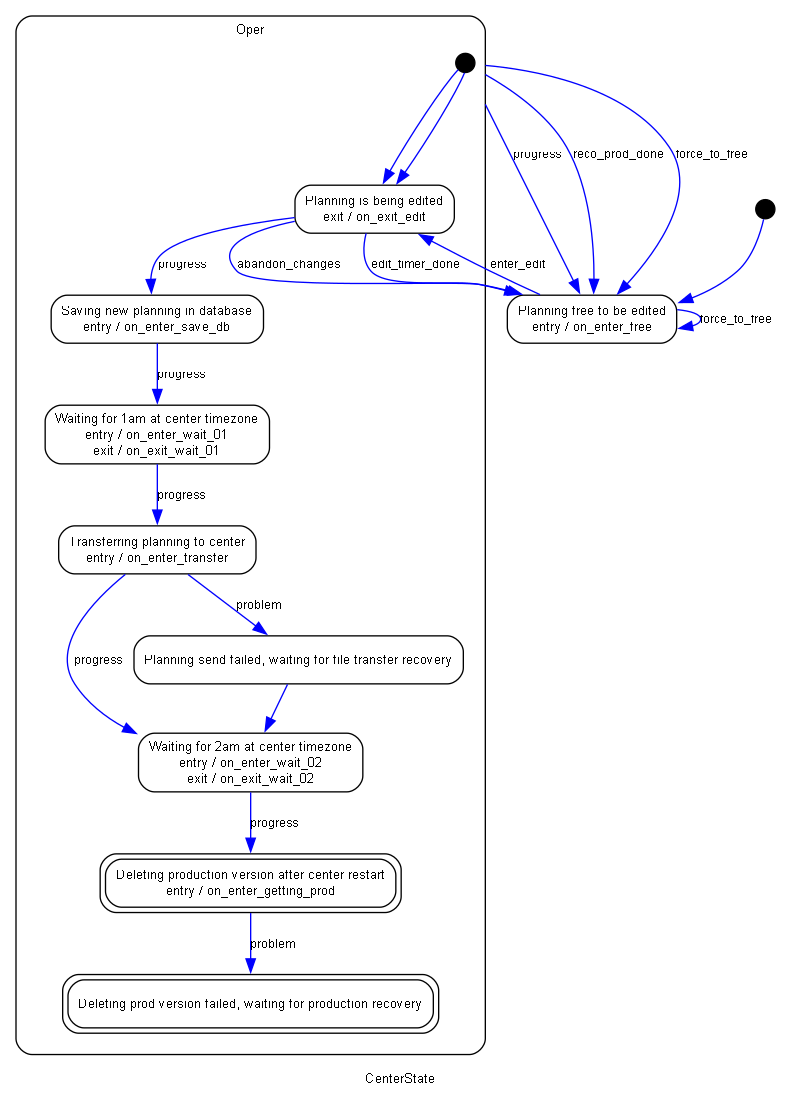

In [2]:
center_state = CenterDataModel(center_name="a_name", testing=True)
sm = CenterState(model=center_state)
the_listener = HistoryListener(model=center_state)
sm.add_listener(the_listener)
show(sm)
#sm

At HH:MM, a_user moved a_name from edit to save_db on progress with: {'success': 'testing: on_enter_save_db'}
delay 3000
At HH:MM, a_user moved a_name from save_db to wait_01 on progress with: {'success': 'testing: on_enter_wait_01 with delay: 3000'}
Canceling delayed event  a_name_wait01
'Enter' for 'success', anything for 'error'
At HH:MM, a_user moved a_name from wait_01 to transfer on progress with: {'success': 'testing: on_enter_transfer'}
At HH:MM, a_user moved a_name from transfer to wait_02 on progress with: {'success': 'testing: on_enter_wait_02 with delay: 3000'}
Canceling delayed event  a_name_wait02
'Enter' for 'success', anything for 'error'
At HH:MM, a_user moved a_name from wait_02 to getting_prod on progress with: {'success': 'testing: on_enter_getting_prod'}
At HH:MM, a_user moved a_name from oper to free on progress with: {'success': 'center is free again'}


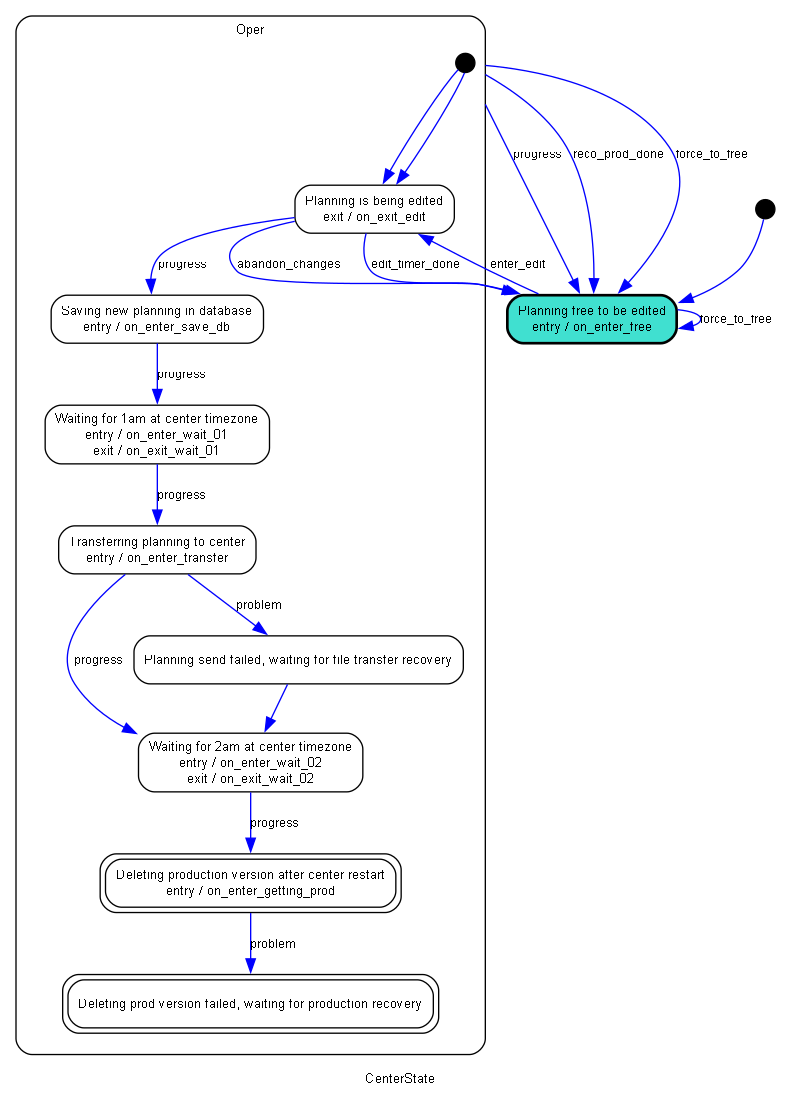

In [4]:
await sm.progress()
show(sm)